## 02 - Exploratory Data Analysis (EDA)

**Input:** the raw file, plus `../reports/data_profile.json` produced by
`01_data_profiling.ipynb` this notebook does not re-derive column roles,
the leakage finding, or the sentinel finding from scratch. It imports them,
so the two notebooks cannot silently drift out of sync.

**Scope:** univariate → bivariate → multivariate exploration of the
*already-audited* dataset: target distribution, numerical and categorical
feature behaviour, relationships with the target, multicollinearity, and
the time structure flagged (but not yet visualised) in Notebook 01.

**Out of scope:** cleaning, imputation, and encoding decisions are not made
here they are informed here and executed in
`03_data_cleaning_preprocessing.ipynb`.

## 0. Environment & Reproducibility

In [1]:
import sys
import json
import hashlib
import warnings
from pathlib import Path

# Make the project's src/ package importable from inside notebooks/
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import save_fig

# Targeted, not blanket: SciPy 1.17 warns that normaltest()/anderson() will
# require an explicit `method=` argument in a future release. The default
# behaviour used here is still correct for this SciPy version - silencing
# only this one FutureWarning, not warnings in general.
warnings.filterwarnings("ignore", category=FutureWarning, module="scipy")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import statsmodels

from scipy.stats import (
    normaltest, anderson, jarque_bera,
    levene, ttest_ind, mannwhitneyu, chi2_contingency,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scipy        : {scipy.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"statsmodels  : {statsmodels.__version__}")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
FIG_DPI = 100

RNG_SEED = 42
np.random.seed(RNG_SEED)

Python       : 3.13.13
pandas       : 2.3.3
numpy        : 2.5.2
scipy        : 1.18.0
scikit-learn : 1.9.0
statsmodels  : 0.14.6


## 1. Load Profiled Data

In [2]:
PROFILE_PATH = Path("../reports/data_profile.json")
RAW_PATH = Path("../data/raw/bank-additional-full.csv")

if not PROFILE_PATH.exists():
    raise FileNotFoundError(
        f"{PROFILE_PATH} not found. Run 01_data_profiling.ipynb first — "
        "this notebook depends on its output."
    )

with open(PROFILE_PATH) as f:
    profile = json.load(f)

if not RAW_PATH.exists():
    raise FileNotFoundError(f"Raw data file not found at {RAW_PATH.resolve()}.")

file_hash = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
if file_hash != profile["source_sha256"]:
    raise ValueError(
        "Raw data file has changed since Notebook 01 profiled it "
        f"(hash mismatch: {file_hash} vs {profile['source_sha256']}). "
        "Re-run Notebook 01 before trusting this EDA."
    )
print("Data file has matches Notebook 01's profile. Proceeding.")

df = pd.read_csv(RAW_PATH, sep=";")

target_col = profile["target_col"]
categorical_cols = profile["categorical_cols"]
numerical_cols = profile["numerical_cols"]
leakage_cols = profile["leakage_cols"]
sentinels = profile["sentinels"]

# The feature set this EDA treats as "modelling-relevant": leakage columns
# are still explored (Section 4.1) to reinforce *why* they're excluded,
# but they are excluded from every other numerical analysis from here on.
model_numerical_features = [c for c in numerical_cols if c not in leakage_cols]

print(f"Rows                    : {df.shape[0]:,}")
print(f"Target                  : {target_col}")
print(f"Categorical features    : {len(categorical_cols)} -> {categorical_cols}")
print(f"Numerical features (all): {len(numerical_cols)} -> {numerical_cols}")
print(f"Leakage columns (Nb 01) : {leakage_cols}")
print(f"Model numerical features: {len(model_numerical_features)} -> {model_numerical_features}")
print(f"Known sentinels (Nb 01) : {sentinels}")

Data file has matches Notebook 01's profile. Proceeding.
Rows                    : 41,188
Target                  : y
Categorical features    : 10 -> ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features (all): 10 -> ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Leakage columns (Nb 01) : ['duration']
Model numerical features: 9 -> ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Known sentinels (Nb 01) : {'pdays': 999}


### 1.1 Handling the `pdays` Sentinel Before Any Statistic Touches It

Notebook 01 found that `pdays == 999` means "never previously contacted"
(96.3% of rows) not a real day count. Every mean, skewness, boxplot,
correlation, or VIF computed on raw `pdays` from here on would be dominated
by this sentinel rather than by the 1,515 rows of real signal. Two derived
views are created **once**, here, and reused everywhere below:

- `pdays_missing` binary flag, 1 where the sentinel is present.
- `pdays_clean` `pdays` with the sentinel replaced by `NaN`, so pandas'
  pairwise-complete handling (`.corr()`, `.skew()`, `.describe()`, etc.)
  naturally uses only the 1,515 genuine values.

In [3]:
sentinel_value = sentinels.get("pdays")

df["pdays_missing"] = (df["pdays"] == sentinel_value).astype(int)
df["pdays_clean"] = df["pdays"].replace(sentinel_value, np.nan)

print(f"pdays_missing == 1: {df['pdays_missing'].sum():,} rows "
      f"({df['pdays_missing'].mean():.1%})")
print()
print("pdays_clean summary (sentinel removed):")
print(df["pdays_clean"].describe())

# From here on, numerical analyses use pdays_clean in place of pdays.
model_numerical_features = [
    "pdays_clean" if c == "pdays" else c for c in model_numerical_features
]
print()
print("Final working numerical feature list for this EDA:")
print(model_numerical_features)

pdays_missing == 1: 39,673 rows (96.3%)

pdays_clean summary (sentinel removed):
count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: pdays_clean, dtype: float64

Final working numerical feature list for this EDA:
['age', 'campaign', 'pdays_clean', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 2. Target Variable - Univariate Analysis & Class Imbalance

This is the first thing a reader of this notebook should see everything
downstream (metric choice, statistical test choice, visualisation choice)
depends on how imbalanced the target is. Notebook 01 already reported the
percentages in a table; here it's shown the way it will actually be
communicated (a chart), and tied back to the success metric already
committed to in Notebook 01.

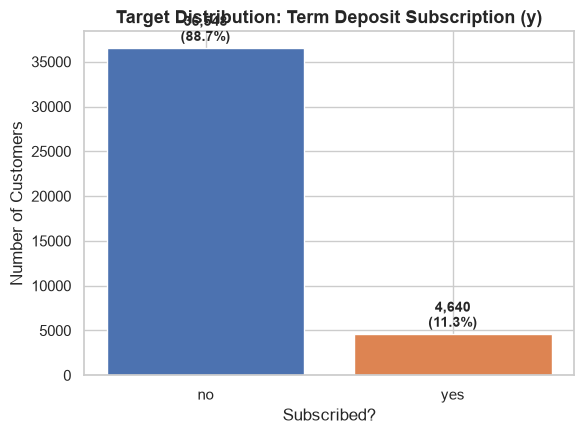

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/02_EDA/target_distribution.png')

In [4]:
target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=FIG_DPI)
bars = ax.bar(target_counts.index, target_counts.values,
              color=["#4C72B0", "#DD8452"])
ax.set_title("Target Distribution: Term Deposit Subscription (y)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Subscribed?")
ax.set_ylabel("Number of Customers")

for bar, pct in zip(bars, target_pct.reindex(target_counts.index)):
    height = bar.get_height()
    ax.annotate(f"{height:,}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
save_fig(fig, "target_distribution", notebook="02_EDA")

**~11.3% positive class.** Consistent with the success criteria already
fixed in Notebook 01: accuracy is not a usable metric here (predicting "no"
for everyone already scores ~89%), so **PR-AUC and lift/capture at the
top-10%/20%** remain the metrics this project optimises for. This also
means every statistical test run below on an n of ~41,000 will have very
high power to detect even trivially small differences a caveat that
matters in Section 5.4.

## 3. Numerical Features - Univariate Analysis

A single reusable grid-plotting helper replaces what was previously
duplicated boxplot/histogram code across the notebook one function,
called with a different plotting function and column list each time.

In [5]:
def plot_feature_grid(data, columns, plot_fn, ncols=3, figsize_per_row=4.2,
                       title_prefix="", save_as=None, notebook="02_EDA", **plot_kwargs):
    """Plot one seaborn/matplotlib chart per column in a grid.

    plot_fn(ax, data, col, **plot_kwargs) draws a single subplot.
    """
    n = len(columns)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(6 * ncols, figsize_per_row * nrows),
                              dpi=FIG_DPI)
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(columns):
        plot_fn(axes[i], data, col, **plot_kwargs)
        axes[i].set_title(f"{title_prefix}{col}", fontsize=11, fontweight="bold")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    if save_as:
        save_fig(fig, save_as, notebook=notebook)
    else:
        plt.show()


def _hist_fn(ax, data, col, **kw):
    sns.histplot(data=data, x=col, kde=True, ax=ax)
    ax.set_xlabel(col); ax.set_ylabel("Frequency")

def _box_fn(ax, data, col, **kw):
    sns.boxplot(x=data[col], ax=ax)
    ax.set_xlabel(col)

def _box_by_target_fn(ax, data, col, target=None, **kw):
    sns.boxplot(data=data, x=target, y=col, ax=ax)
    ax.set_xlabel("Campaign Response"); ax.set_ylabel(col)

def _violin_by_target_fn(ax, data, col, target=None, **kw):
    sns.violinplot(data=data, x=target, y=col, ax=ax)
    ax.set_xlabel("Campaign Response"); ax.set_ylabel(col)

def _bar_freq_fn(ax, data, col, **kw):
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, ax=ax)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40)

def _rate_by_cat_fn(ax, data, col, target=None, positive_label=None, **kw):
    rate = (data.groupby(col)[target]
                 .apply(lambda s: (s == positive_label).mean())
                 .sort_values(ascending=False))
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color="#4C72B0")
    ax.axhline(profile["target_positive_rate"], color="red", linestyle="--",
               linewidth=1, label="Overall rate")
    ax.set_xlabel(""); ax.set_ylabel("Subscription rate")
    ax.tick_params(axis="x", rotation=40)
    ax.legend(fontsize=8)

print("Plotting helpers ready.")

Plotting helpers ready.


### 3.1 Distributions (Histogram + KDE)

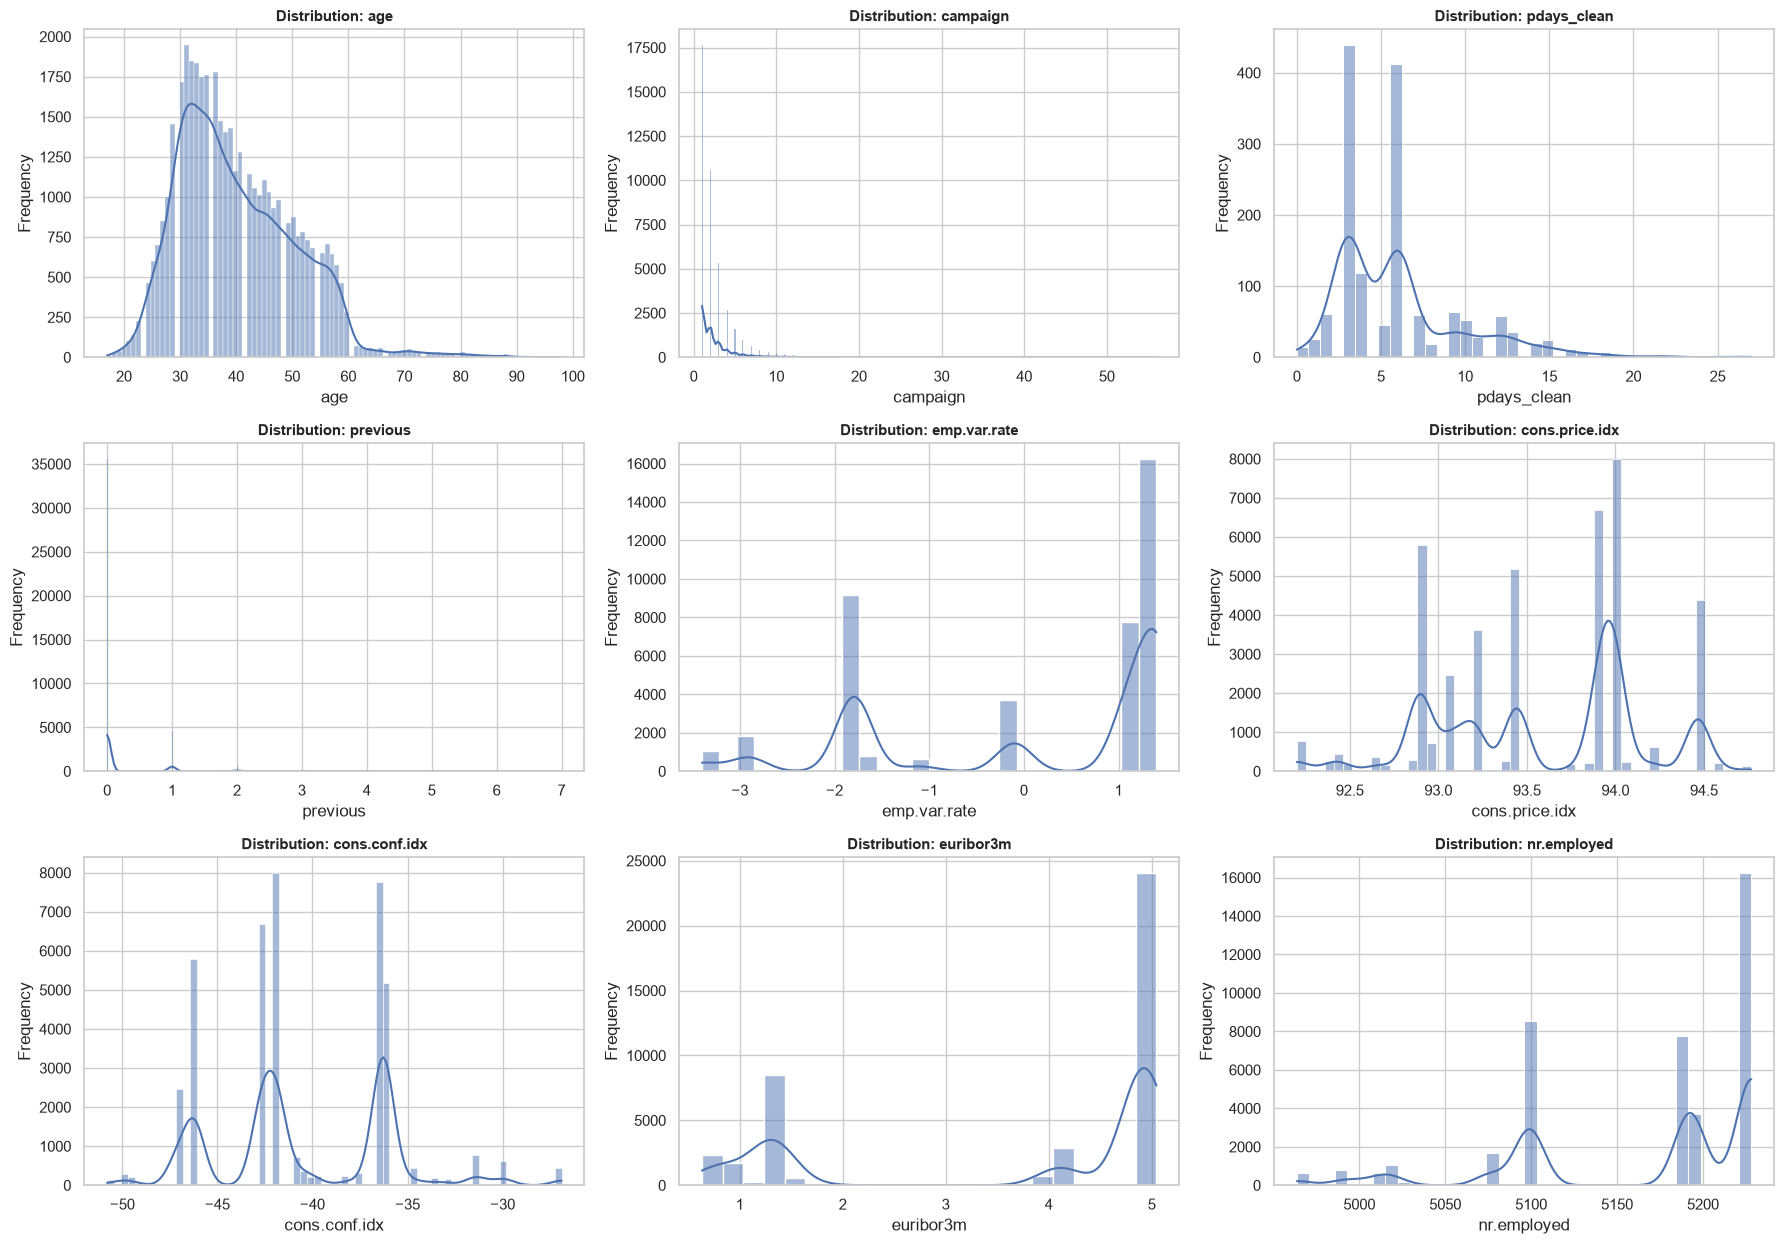

In [6]:
plot_feature_grid(df, model_numerical_features, _hist_fn, ncols=3,
                   title_prefix="Distribution: ", save_as="numeric_feature_distributions")

### 3.2 Boxplots (Outlier Screening)

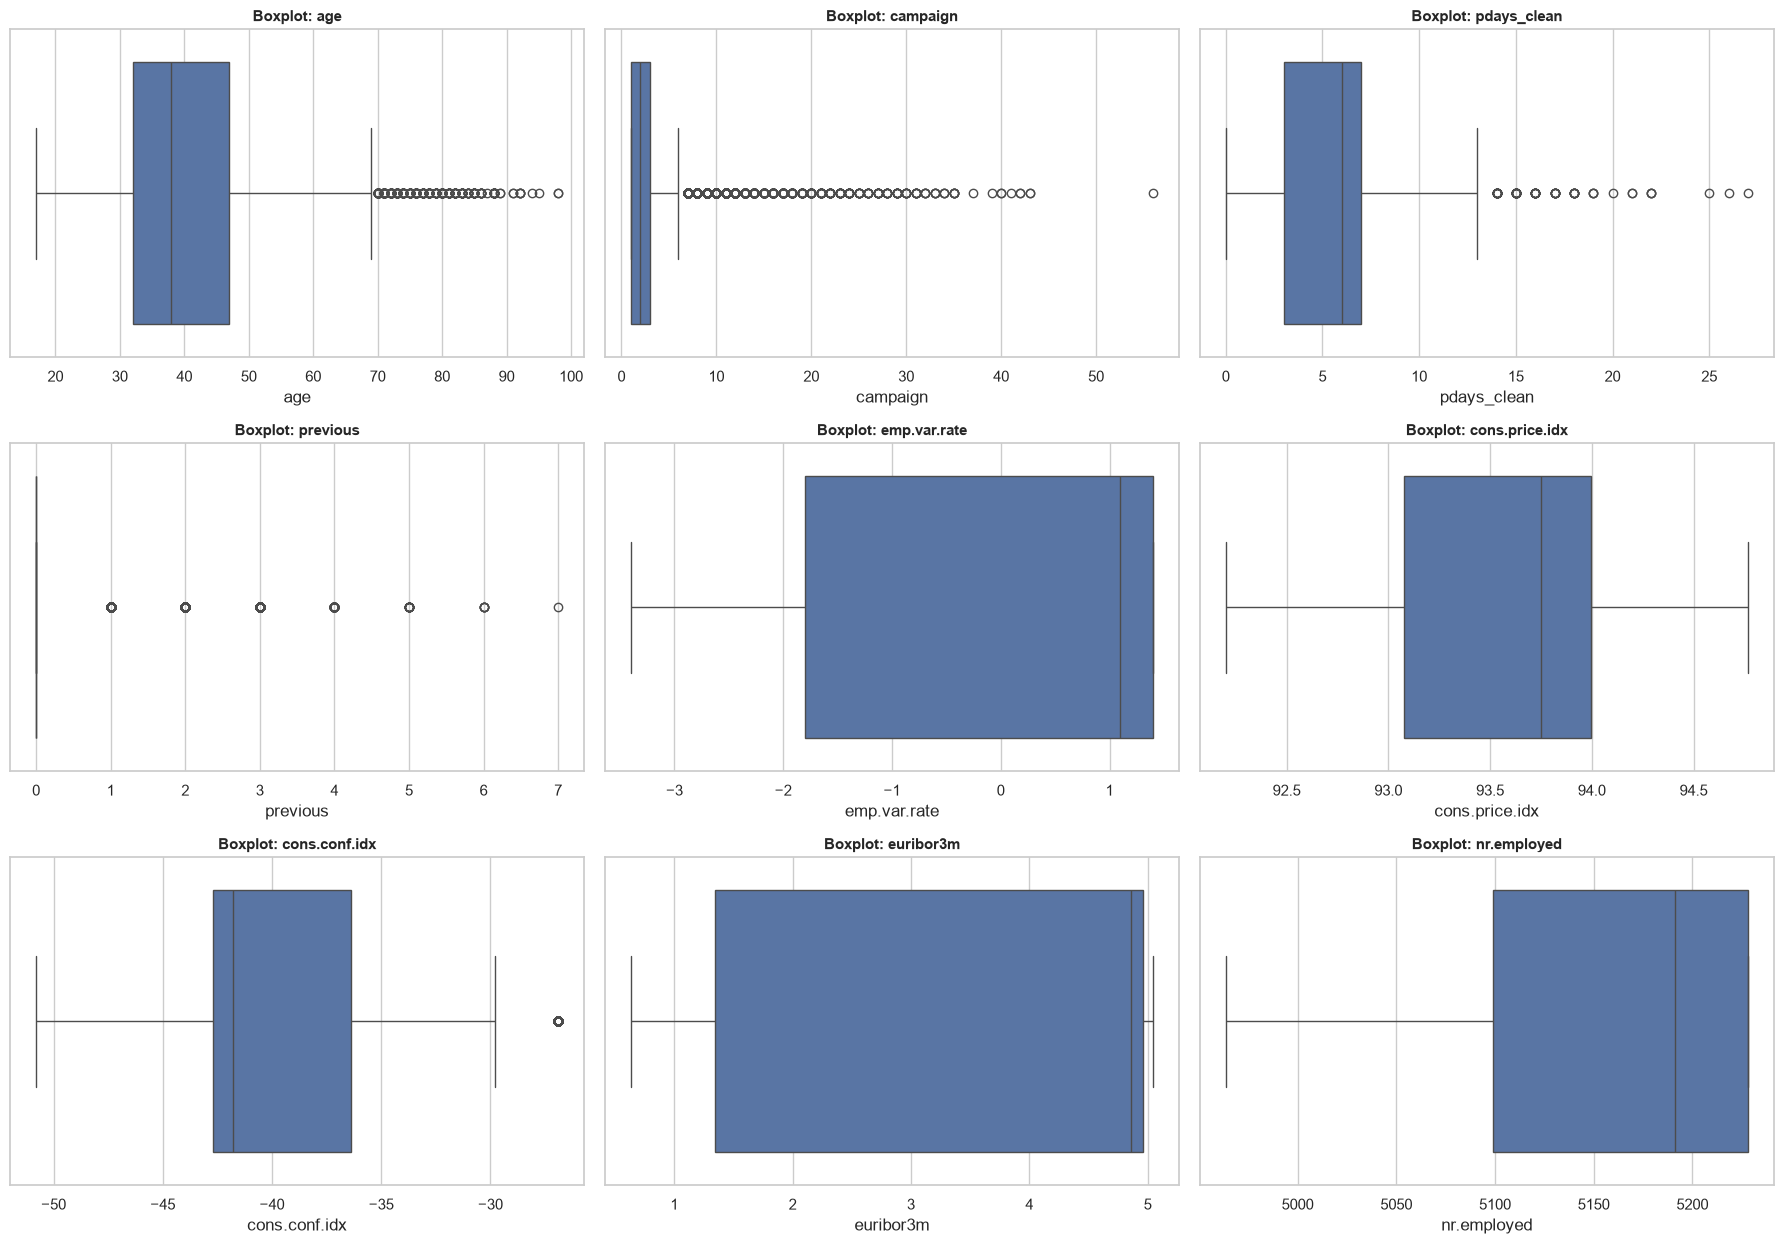

In [7]:
plot_feature_grid(df, model_numerical_features, _box_fn, ncols=3,
                   title_prefix="Boxplot: ", save_as="numeric_feature_boxplots")

### 3.3 Skewness Summary

Computed on `pdays_clean`, not raw `pdays` otherwise the 999-sentinel
alone would make `pdays` look like an extreme-skew outlier column, which
would be an artifact of the sentinel, not a real distributional property.

In [8]:
skew_summary = pd.DataFrame({
    "Feature": model_numerical_features,
    "Skewness": [df[c].skew() for c in model_numerical_features],
})

def classify_skewness(value):
    abs_value = abs(value)
    if abs_value < 0.5:
        return "Approximately Symmetric"
    elif abs_value < 1:
        return "Moderately Skewed"
    return "Highly Skewed"

skew_summary["Skewness_Level"] = skew_summary["Skewness"].apply(classify_skewness)
skew_summary = (skew_summary
                .reindex(skew_summary["Skewness"].abs().sort_values(ascending=False).index)
                .reset_index(drop=True))
skew_summary

,Feature,Skewness,Skewness_Level
0,campaign,4.762507,Highly Skewed
1,previous,3.832042,Highly Skewed
2,pdays_clean,1.458564,Highly Skewed
3,nr.employed,-1.044262,Highly Skewed
4,age,0.784697,Moderately Skewed
5,emp.var.rate,-0.724096,Moderately Skewed
6,euribor3m,-0.709188,Moderately Skewed
7,cons.conf.idx,0.303180,Approximately Symmetric
8,cons.price.idx,-0.230888,Approximately Symmetric


### 3.4 `duration` Shown Once, For the Record, Then Set Aside

Notebook 01 proved `duration` is target leakage (correlation 0.41 with the
target; every `duration == 0` call resulted in "no"). It is deliberately
**excluded from every analysis above and below this cell**. It's shown
here, once, purely so the leakage is visible in this notebook too not as
a feature under consideration.

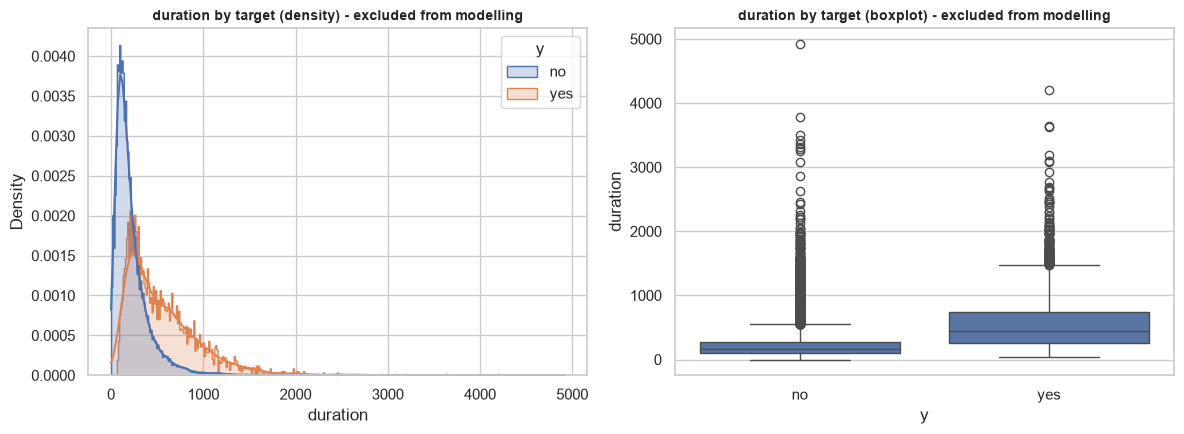

Correlation(duration, target): 0.405  (reference from Notebook 01; not used downstream)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=FIG_DPI)
sns.histplot(data=df, x="duration", hue=target_col, kde=True, ax=axes[0],
             element="step", stat="density", common_norm=False)
axes[0].set_title("duration by target (density) - excluded from modelling",
                   fontsize=10, fontweight="bold")
sns.boxplot(data=df, x=target_col, y="duration", ax=axes[1])
axes[1].set_title("duration by target (boxplot) - excluded from modelling",
                   fontsize=10, fontweight="bold")
plt.tight_layout()
save_fig(fig, "duration_by_target", notebook="02_EDA")

print(f"Correlation(duration, target): "
      f"{df['duration'].corr((df[target_col] == 'yes').astype(int)):.3f}  "
      f"(reference from Notebook 01; not used downstream)")

## 4. Categorical Features - Univariate Analysis

Notebook 01 listed every category's exact count in a table. This section
adds what a table alone doesn't give a reader: the *shape* of each
distribution which categories dominate, and how small the disguised-missing
`"unknown"` slice actually looks next to the real categories.

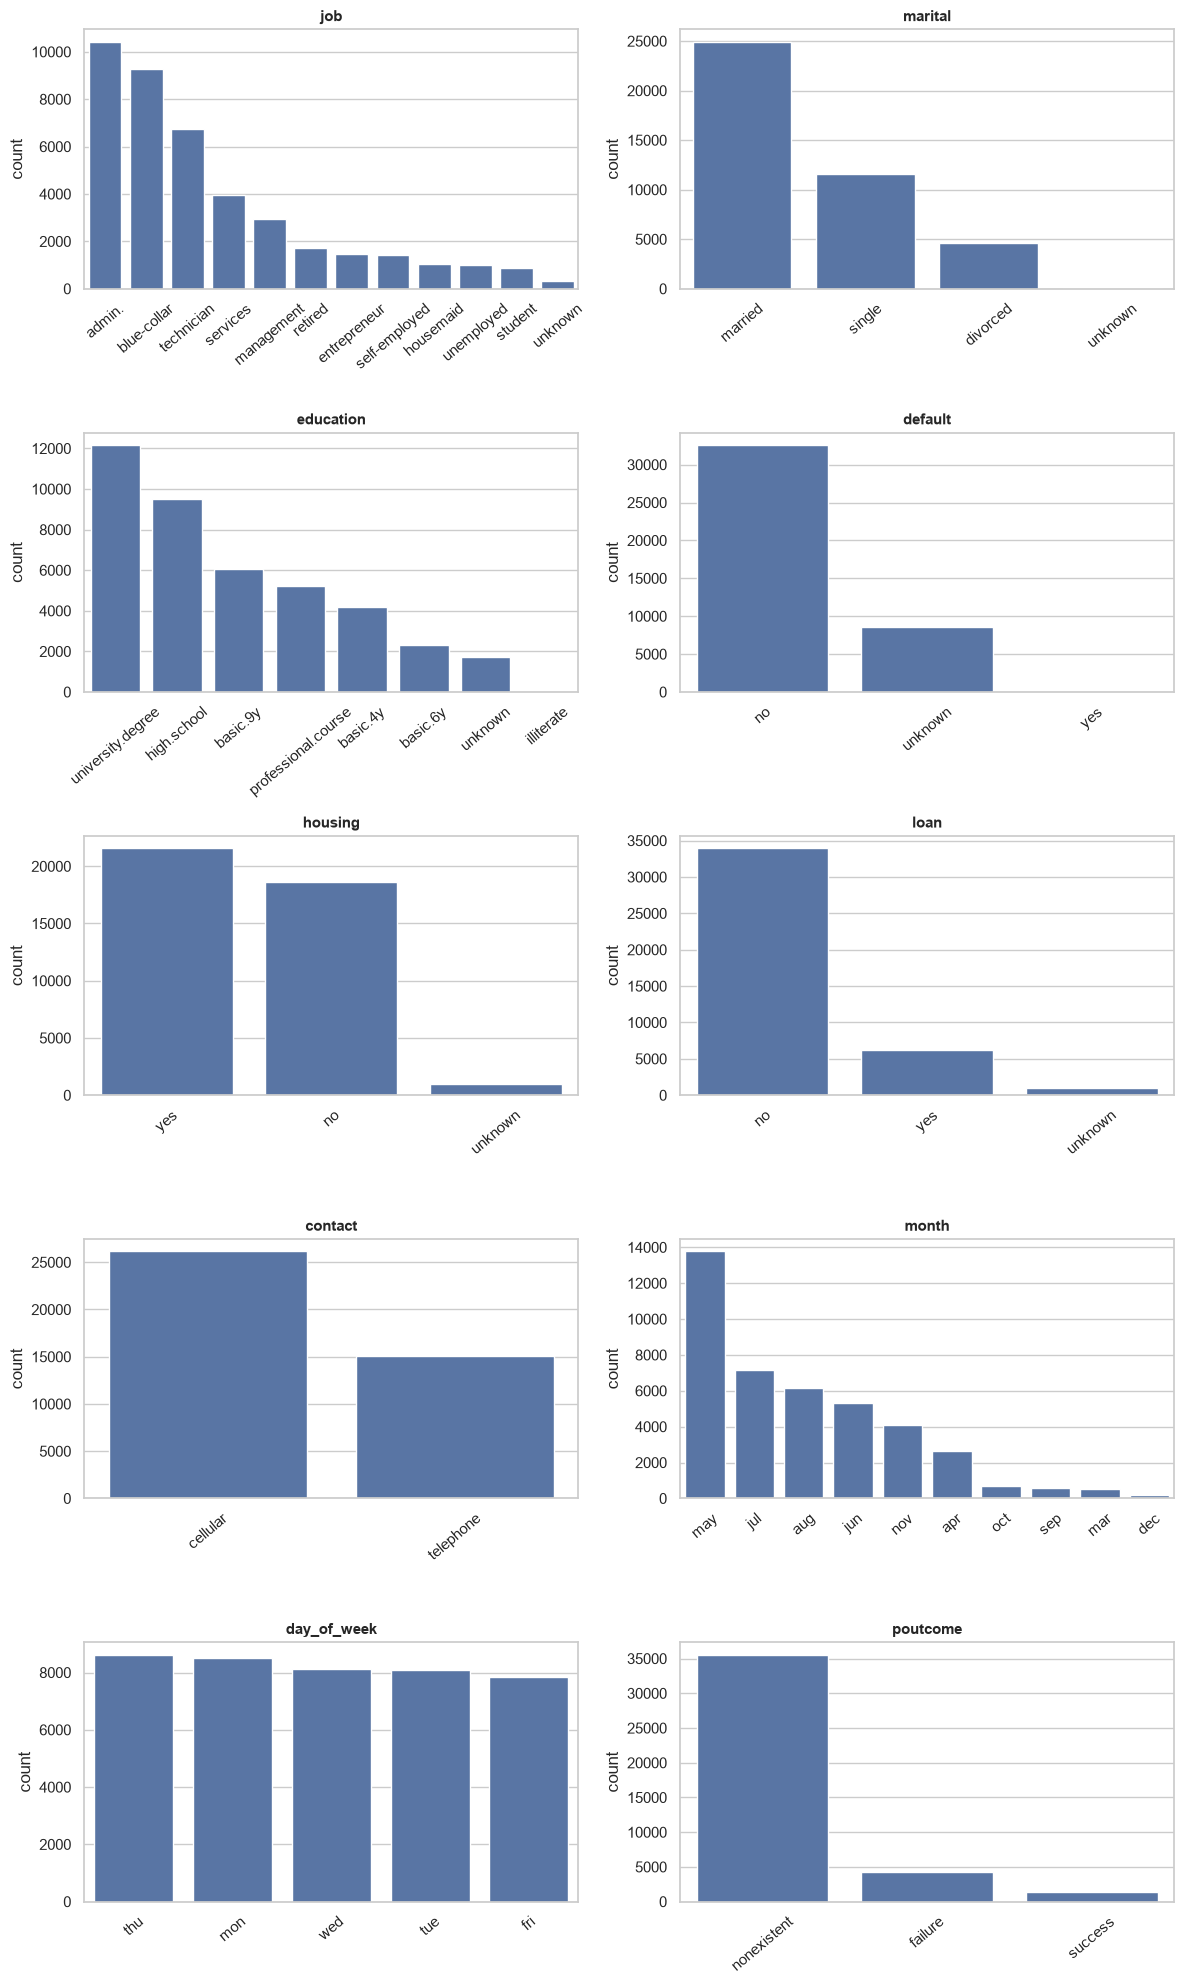

In [10]:
plot_feature_grid(df, categorical_cols, _bar_freq_fn, ncols=2, figsize_per_row=4,
                   title_prefix="", save_as="categorical_feature_frequencies")

## 5. Numerical Features vs. Target - Bivariate Analysis

### 5.1 Group Summary Statistics

In [11]:
group_summary_rows = []
for col in model_numerical_features:
    g = df.groupby(target_col)[col].agg(Count="count", Mean="mean",
                                         Median="median", Std="std").reset_index()
    for _, row in g.iterrows():
        group_summary_rows.append({
            "Feature": col, "Target_Group": row[target_col], "Count": row["Count"],
            "Mean": row["Mean"], "Median": row["Median"], "Std": row["Std"],
        })

mean_comparison_summary = pd.DataFrame(group_summary_rows)
mean_comparison_summary

,Feature,Target_Group,Count,Mean,Median,Std
0,age,no,36548,39.911185,38.000,9.898132
1,age,yes,4640,40.913147,37.000,13.837476
2,campaign,no,36548,2.633085,2.000,2.873438
3,campaign,yes,4640,2.051724,2.000,1.666245
4,pdays_clean,no,548,6.193431,6.000,3.987525
5,pdays_clean,yes,967,5.913133,6.000,3.727896
6,previous,no,36548,0.132374,0.000,0.409199
7,previous,yes,4640,0.492672,0.000,0.860344
8,emp.var.rate,no,36548,0.248875,1.100,1.482932
9,emp.var.rate,yes,4640,-1.233448,-1.800,1.623626


### 5.2 Normality Assessment

Three formal tests are run for completeness, but with n ≈ 41,000, formal
normality tests (D'Agostino, Anderson-Darling, Jarque-Bera) will reject
normality for almost any real-world feature the tests have enormous
power to detect trivial deviations that don't matter practically. The
skewness/kurtosis heuristic below is what actually drives the test-choice
decision in Section 5.4; the formal test columns are kept for transparency,
not used as the deciding rule.

In [12]:
normality_results = []
for col in model_numerical_features:
    data = df[col].dropna()
    skewness = data.skew()
    kurtosis = data.kurtosis()
    dagostino_stat, dagostino_p = normaltest(data)
    anderson_result = anderson(data, dist="norm")
    idx5 = np.argmin(np.abs(anderson_result.significance_level - 5.0))
    anderson_critical_5 = anderson_result.critical_values[idx5]
    anderson_normal = anderson_result.statistic < anderson_critical_5
    jb_stat, jb_p = jarque_bera(data)

    normality_results.append({
        "Feature": col, "Skewness": skewness, "Kurtosis": kurtosis,
        "DAgostino_Statistic": dagostino_stat, "DAgostino_p": dagostino_p,
        "Anderson_Statistic": anderson_result.statistic,
        "Anderson_Critical_5pct": anderson_critical_5, "Anderson_Normal": anderson_normal,
        "JarqueBera_Statistic": jb_stat, "JarqueBera_p": jb_p,
    })

normality_summary = pd.DataFrame(normality_results)

def classify_normality(row):
    skew, kurt = abs(row["Skewness"]), abs(row["Kurtosis"])
    if skew < 0.5 and kurt < 1:
        return "Approximately Normal / Symmetric"
    elif skew < 1 and kurt < 3:
        return "Moderately Non-Normal"
    return "Strongly Non-Normal"

normality_summary["Normality_Level"] = normality_summary.apply(classify_normality, axis=1)
n_rejected_formal = int((normality_summary["DAgostino_p"] < 0.05).sum())
print(f"Formal tests reject normality for {n_rejected_formal}/{len(model_numerical_features)} "
      f"features at alpha=0.05 (expected, given n={len(df):,}) heuristic used instead.")
normality_summary[["Feature", "Skewness", "Kurtosis", "DAgostino_p",
                    "Anderson_Normal", "JarqueBera_p", "Normality_Level"]]

C:\Users\User\AppData\Local\Temp\ipykernel_24296\2765274091.py:7: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_result = anderson(data, dist="norm")


Formal tests reject normality for 9/9 features at alpha=0.05 (expected, given n=41,188) heuristic used instead.


,Feature,Skewness,Kurtosis,DAgostino_p,Anderson_Normal,JarqueBera_p,Normality_Level
0,age,0.784697,0.791312,0.000000e+00,False,0.000000e+00,Moderately Non-Normal
1,campaign,4.762507,36.979795,0.000000e+00,False,0.000000e+00,Strongly Non-Normal
2,pdays_clean,1.458564,2.564562,2.415298e-88,False,2.009410e-206,Strongly Non-Normal
3,previous,3.832042,20.108816,0.000000e+00,False,0.000000e+00,Strongly Non-Normal
4,emp.var.rate,-0.724096,-1.062632,0.000000e+00,False,0.000000e+00,Moderately Non-Normal
5,cons.price.idx,-0.230888,-0.829809,0.000000e+00,False,0.000000e+00,Approximately Normal / Symmetric
6,cons.conf.idx,0.303180,-0.358558,4.666821e-204,False,1.134705e-185,Approximately Normal / Symmetric
7,euribor3m,-0.709188,-1.406803,0.000000e+00,False,0.000000e+00,Moderately Non-Normal
8,nr.employed,-1.044262,-0.003760,0.000000e+00,False,0.000000e+00,Strongly Non-Normal


### 5.3 Equal-Variance Assumption (Levene's Test)

In [13]:
assumption_results = []
for col in model_numerical_features:
    group_no = df.loc[df[target_col] == "no", col].dropna()
    group_yes = df.loc[df[target_col] == "yes", col].dropna()
    stat, p = levene(group_no, group_yes, center="median")
    assumption_results.append({
        "Feature": col, "No_Count": len(group_no), "Yes_Count": len(group_yes),
        "No_Variance": group_no.var(), "Yes_Variance": group_yes.var(),
        "Levene_Statistic": stat, "Levene_p_value": p,
    })

assumption_summary = pd.DataFrame(assumption_results)
assumption_summary

,Feature,No_Count,Yes_Count,No_Variance,Yes_Variance,Levene_Statistic,Levene_p_value
0,age,36548,4640,97.973013,191.475749,689.322840,1.096398e-150
1,campaign,36548,4640,8.256647,2.776371,127.707118,1.438210e-29
2,pdays_clean,548,967,15.900359,13.897208,7.626627,5.820805e-03
3,previous,36548,4640,0.167444,0.740192,2304.257088,0.000000e+00
4,emp.var.rate,36548,4640,2.199086,2.636161,26.155089,3.164752e-07
5,cons.price.idx,36548,4640,0.312473,0.457847,237.422417,2.023126e-53
6,cons.conf.idx,36548,4640,19.282238,37.695520,1048.471450,3.747063e-227
7,euribor3m,36548,4640,2.683658,3.036648,23.775073,1.086785e-06
8,nr.employed,36548,4640,4169.540468,7668.967371,1037.951766,6.363730e-225


### 5.4 Statistical Test + Effect Size

Test choice per feature: normality heuristic picks t-test vs. Mann-Whitney U;
Levene's result picks Welch's vs. Student's t-test when the parametric branch
is used. **Effect size (Cohen's d) is the number to read, not the p-value**
at n ≈ 41,000, even a difference of a fraction of a unit will produce
p < 0.001 regardless of whether it matters for the model.

In [14]:
test_results = []
for col in model_numerical_features:
    group_no = df.loc[df[target_col] == "no", col].dropna()
    group_yes = df.loc[df[target_col] == "yes", col].dropna()

    normality_level = normality_summary.loc[
        normality_summary["Feature"] == col, "Normality_Level"].iloc[0]
    levene_p = assumption_summary.loc[
        assumption_summary["Feature"] == col, "Levene_p_value"].iloc[0]

    if normality_level == "Approximately Normal / Symmetric":
        equal_var = levene_p > 0.05
        statistic, p_value = ttest_ind(group_no, group_yes, equal_var=equal_var)
        selected_test = "Independent t-test" if equal_var else "Welch's t-test"
    else:
        statistic, p_value = mannwhitneyu(group_no, group_yes, alternative="two-sided")
        selected_test = "Mann-Whitney U"

    mean_no, mean_yes = group_no.mean(), group_yes.mean()
    mean_difference = mean_yes - mean_no

    n1, n2 = len(group_no), len(group_yes)
    pooled_std = np.sqrt(((n1 - 1) * group_no.var() + (n2 - 1) * group_yes.var())
                          / (n1 + n2 - 2))
    cohens_d = mean_difference / pooled_std

    test_results.append({
        "Feature": col, "Test": selected_test, "Statistic": statistic,
        "p_value": p_value, "Mean_No": mean_no, "Mean_Yes": mean_yes,
        "Mean_Difference": mean_difference, "Cohens_d": cohens_d,
    })

mean_comparison_results = pd.DataFrame(test_results)

def classify_effect_size(d):
    abs_d = abs(d)
    if abs_d < 0.2: return "Negligible"
    elif abs_d < 0.5: return "Small"
    elif abs_d < 0.8: return "Medium"
    return "Large"

mean_comparison_results["Effect_Size"] = mean_comparison_results["Cohens_d"].apply(classify_effect_size)
mean_comparison_results["Significance"] = mean_comparison_results["p_value"].apply(
    lambda p: "Significant" if p <= 0.05 else "Not Significant")
mean_comparison_results["Direction"] = mean_comparison_results["Mean_Difference"].apply(
    lambda x: "Higher in y=yes" if x > 0 else "Higher in y=no")

(mean_comparison_results
 .sort_values("Cohens_d", key=abs, ascending=False)
 .reset_index(drop=True)
 [["Feature", "Test", "p_value", "Significance", "Cohens_d", "Effect_Size", "Direction"]])

,Feature,Test,p_value,Significance,Cohens_d,Effect_Size,Direction
0,nr.employed,Mann-Whitney U,0.000000e+00,Significant,-1.199769,Large,Higher in y=no
1,euribor3m,Mann-Whitney U,0.000000e+00,Significant,-1.023074,Large,Higher in y=no
2,emp.var.rate,Mann-Whitney U,0.000000e+00,Significant,-0.988586,Large,Higher in y=no
3,previous,Mann-Whitney U,0.000000e+00,Significant,0.748101,Medium,Higher in y=yes
4,cons.price.idx,Welch's t-test,6.916521e-122,Significant,-0.434859,Small,Higher in y=no
5,campaign,Mann-Whitney U,3.418527e-38,Significant,-0.210338,Small,Higher in y=no
6,cons.conf.idx,Welch's t-test,7.588202e-18,Significant,0.173829,Negligible,Higher in y=yes
7,age,Mann-Whitney U,1.608054e-02,Significant,0.096189,Negligible,Higher in y=yes
8,pdays_clean,Mann-Whitney U,3.845654e-01,Not Significant,-0.073303,Negligible,Higher in y=no


### 5.5 Visual Comparison by Target

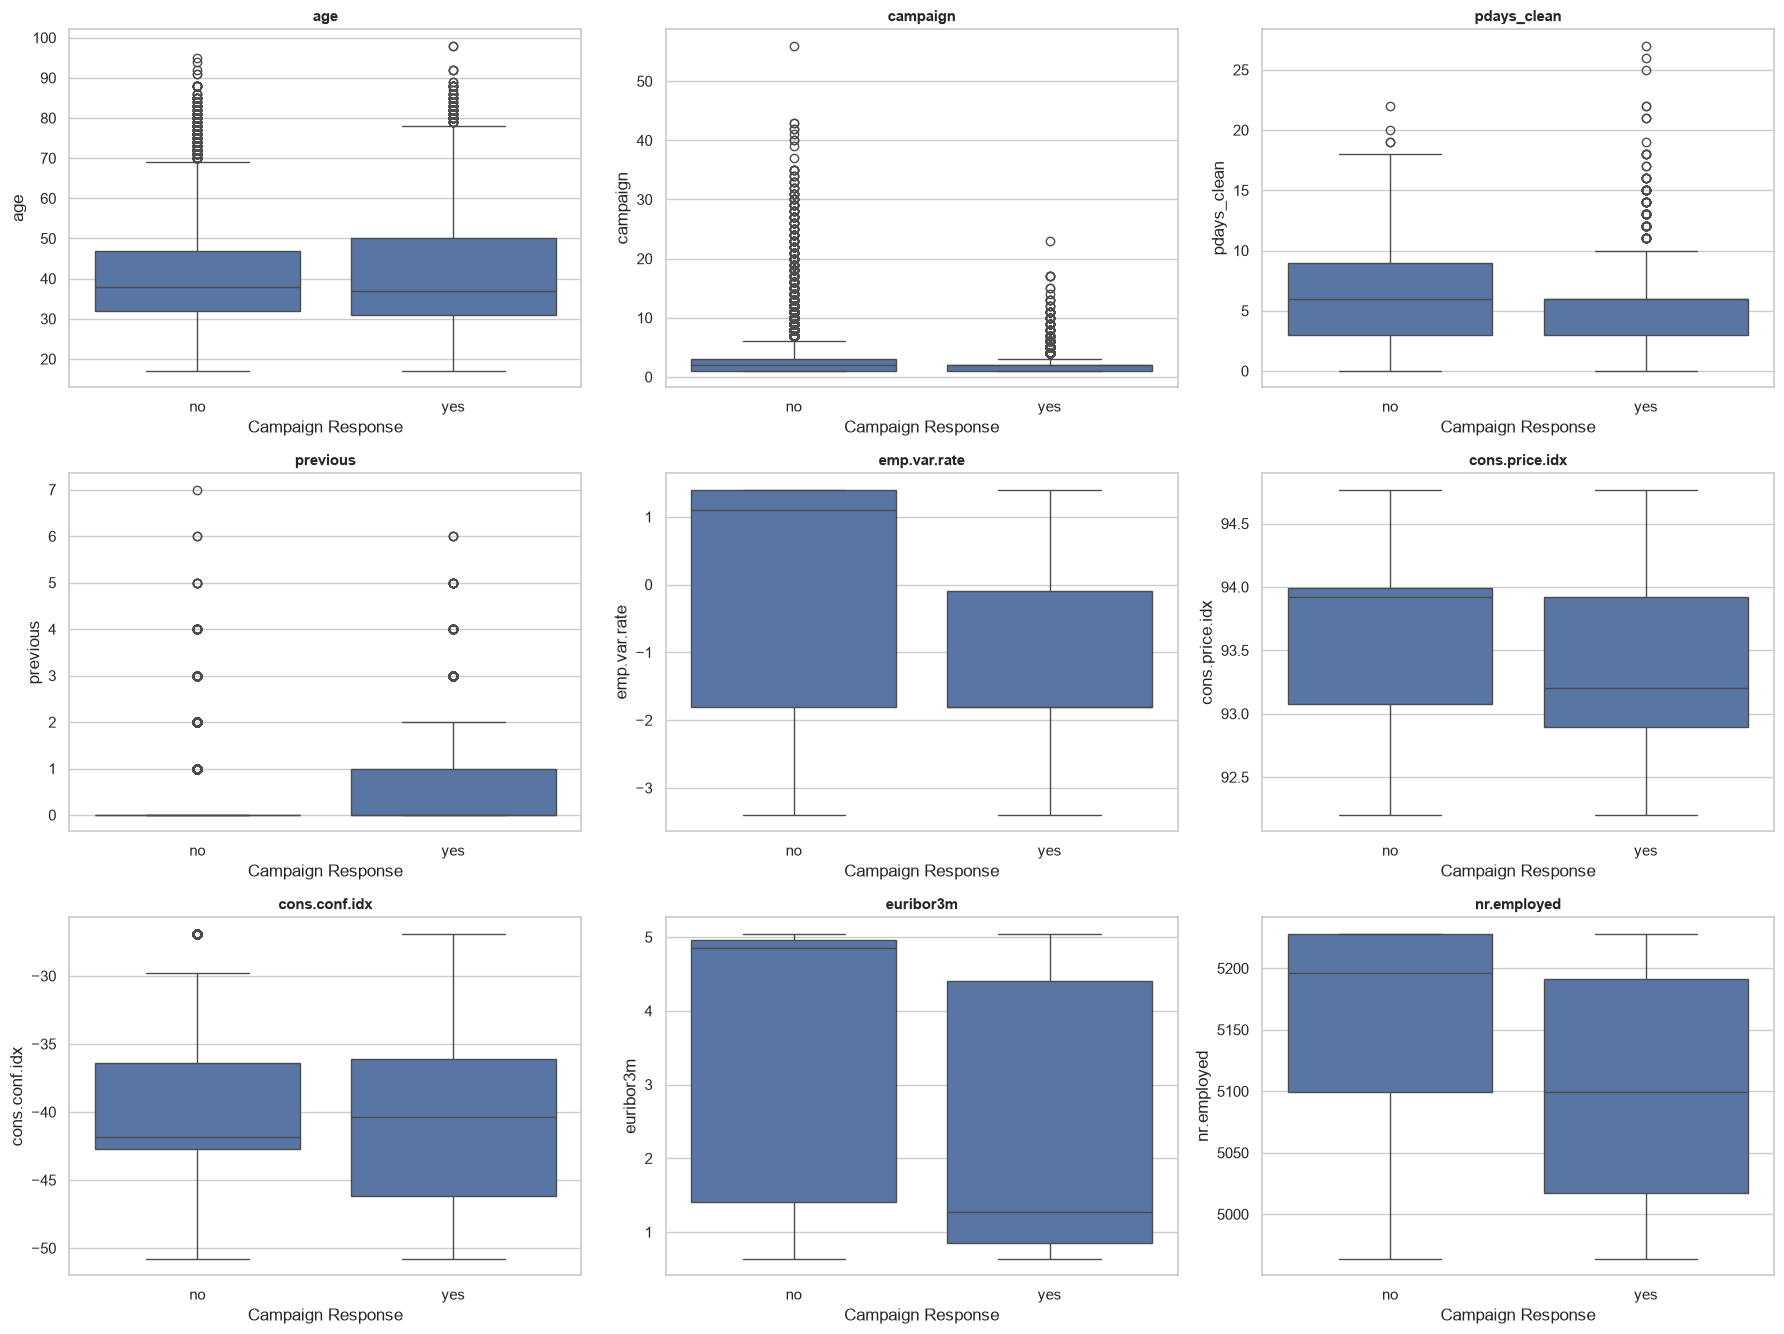

In [15]:
plot_feature_grid(df, model_numerical_features, _box_by_target_fn, ncols=3,
                   figsize_per_row=4.5, target=target_col,
                   title_prefix="", save_as="numeric_features_boxplot_by_target")

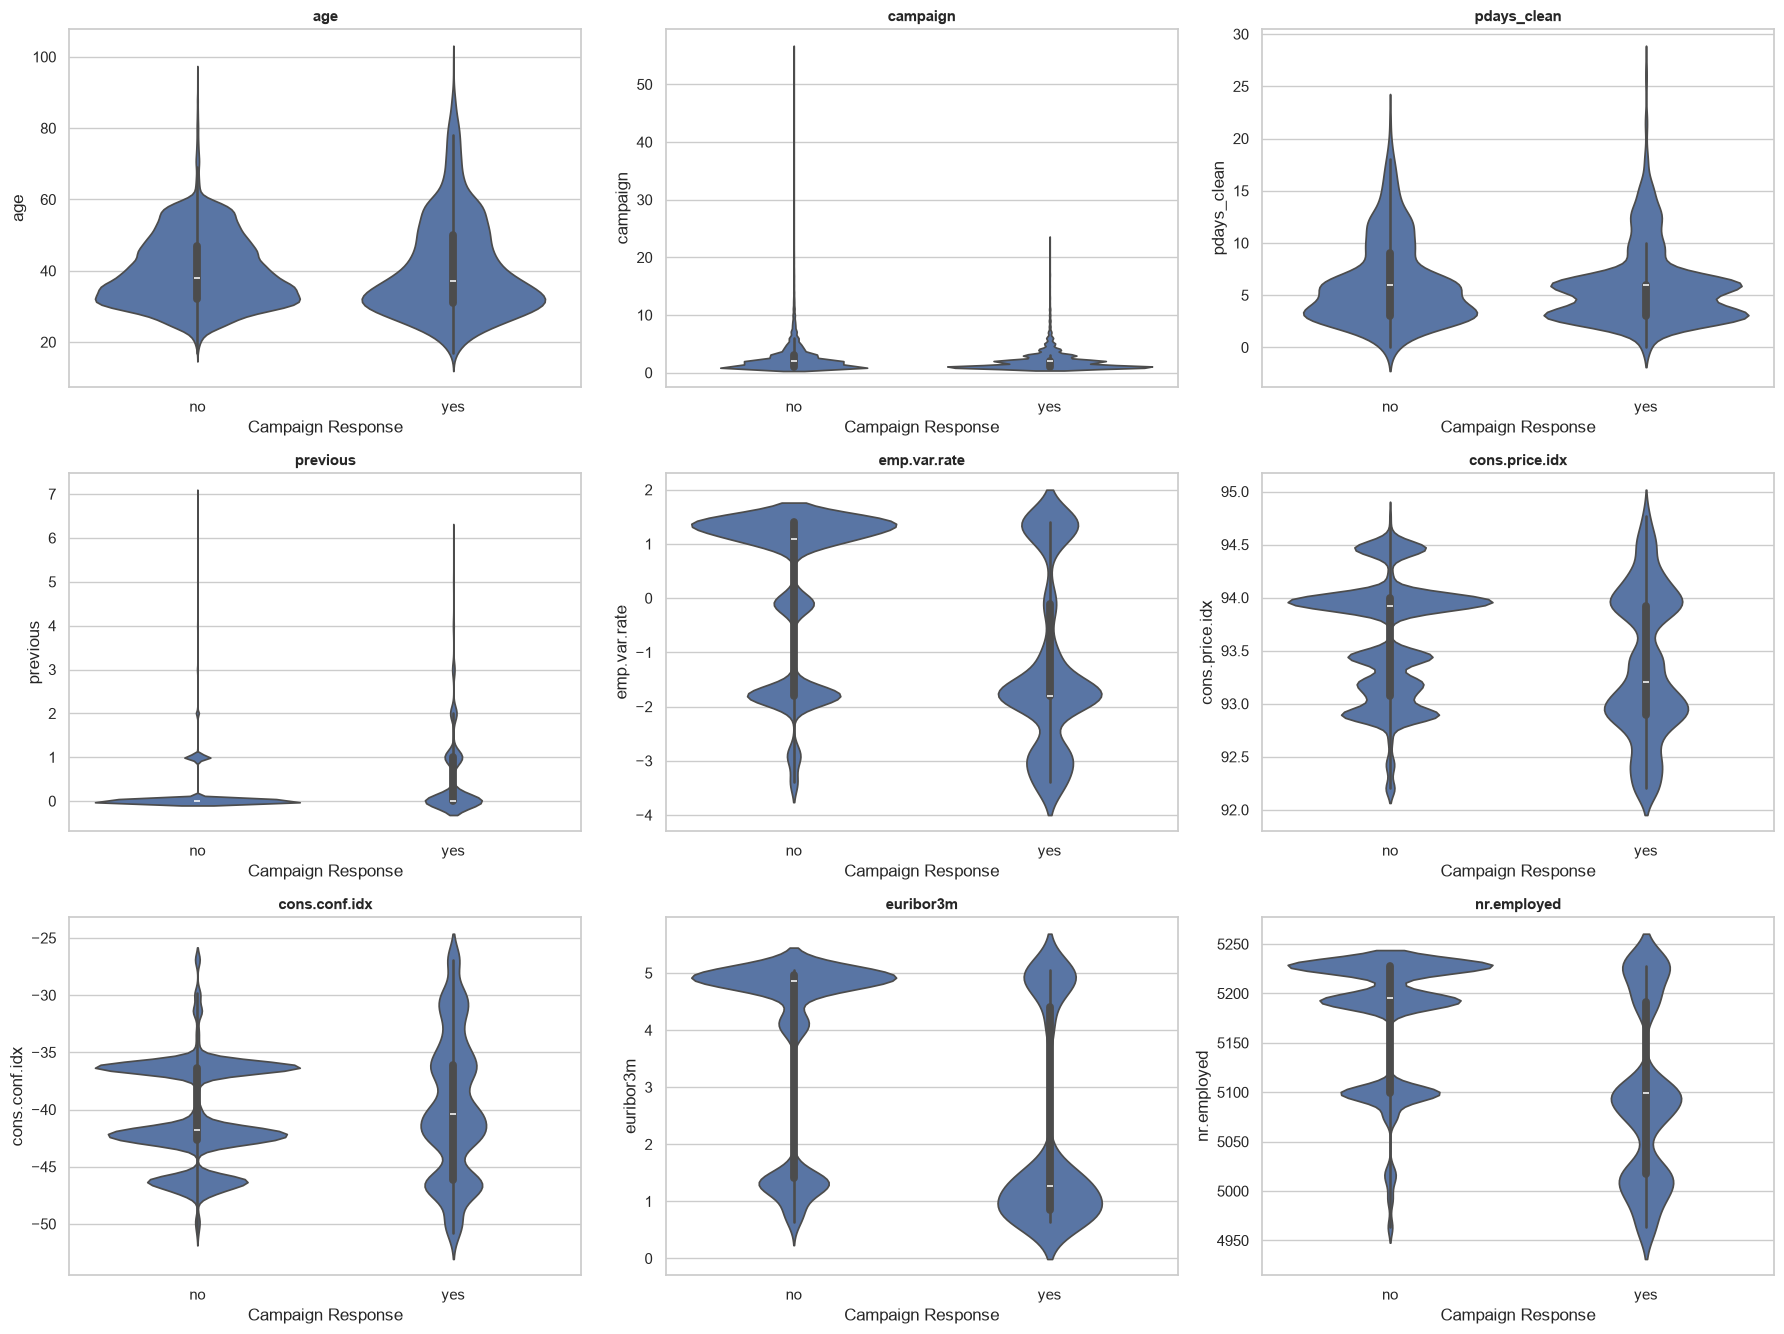

In [16]:
plot_feature_grid(df, model_numerical_features, _violin_by_target_fn, ncols=3,
                   figsize_per_row=4.5, target=target_col,
                   title_prefix="", save_as="numeric_features_violin_by_target")

## 6. Categorical Features vs. Target - Bivariate Analysis

### 6.1 Subscription Rate by Category

This is the visual the previous version of this notebook never produced
a chi-square p-value says *whether* a category matters, not *which levels*
drive it or *by how much*. The red line marks the overall base rate
(~11.3%) so each category's lift above/below baseline is visible directly.

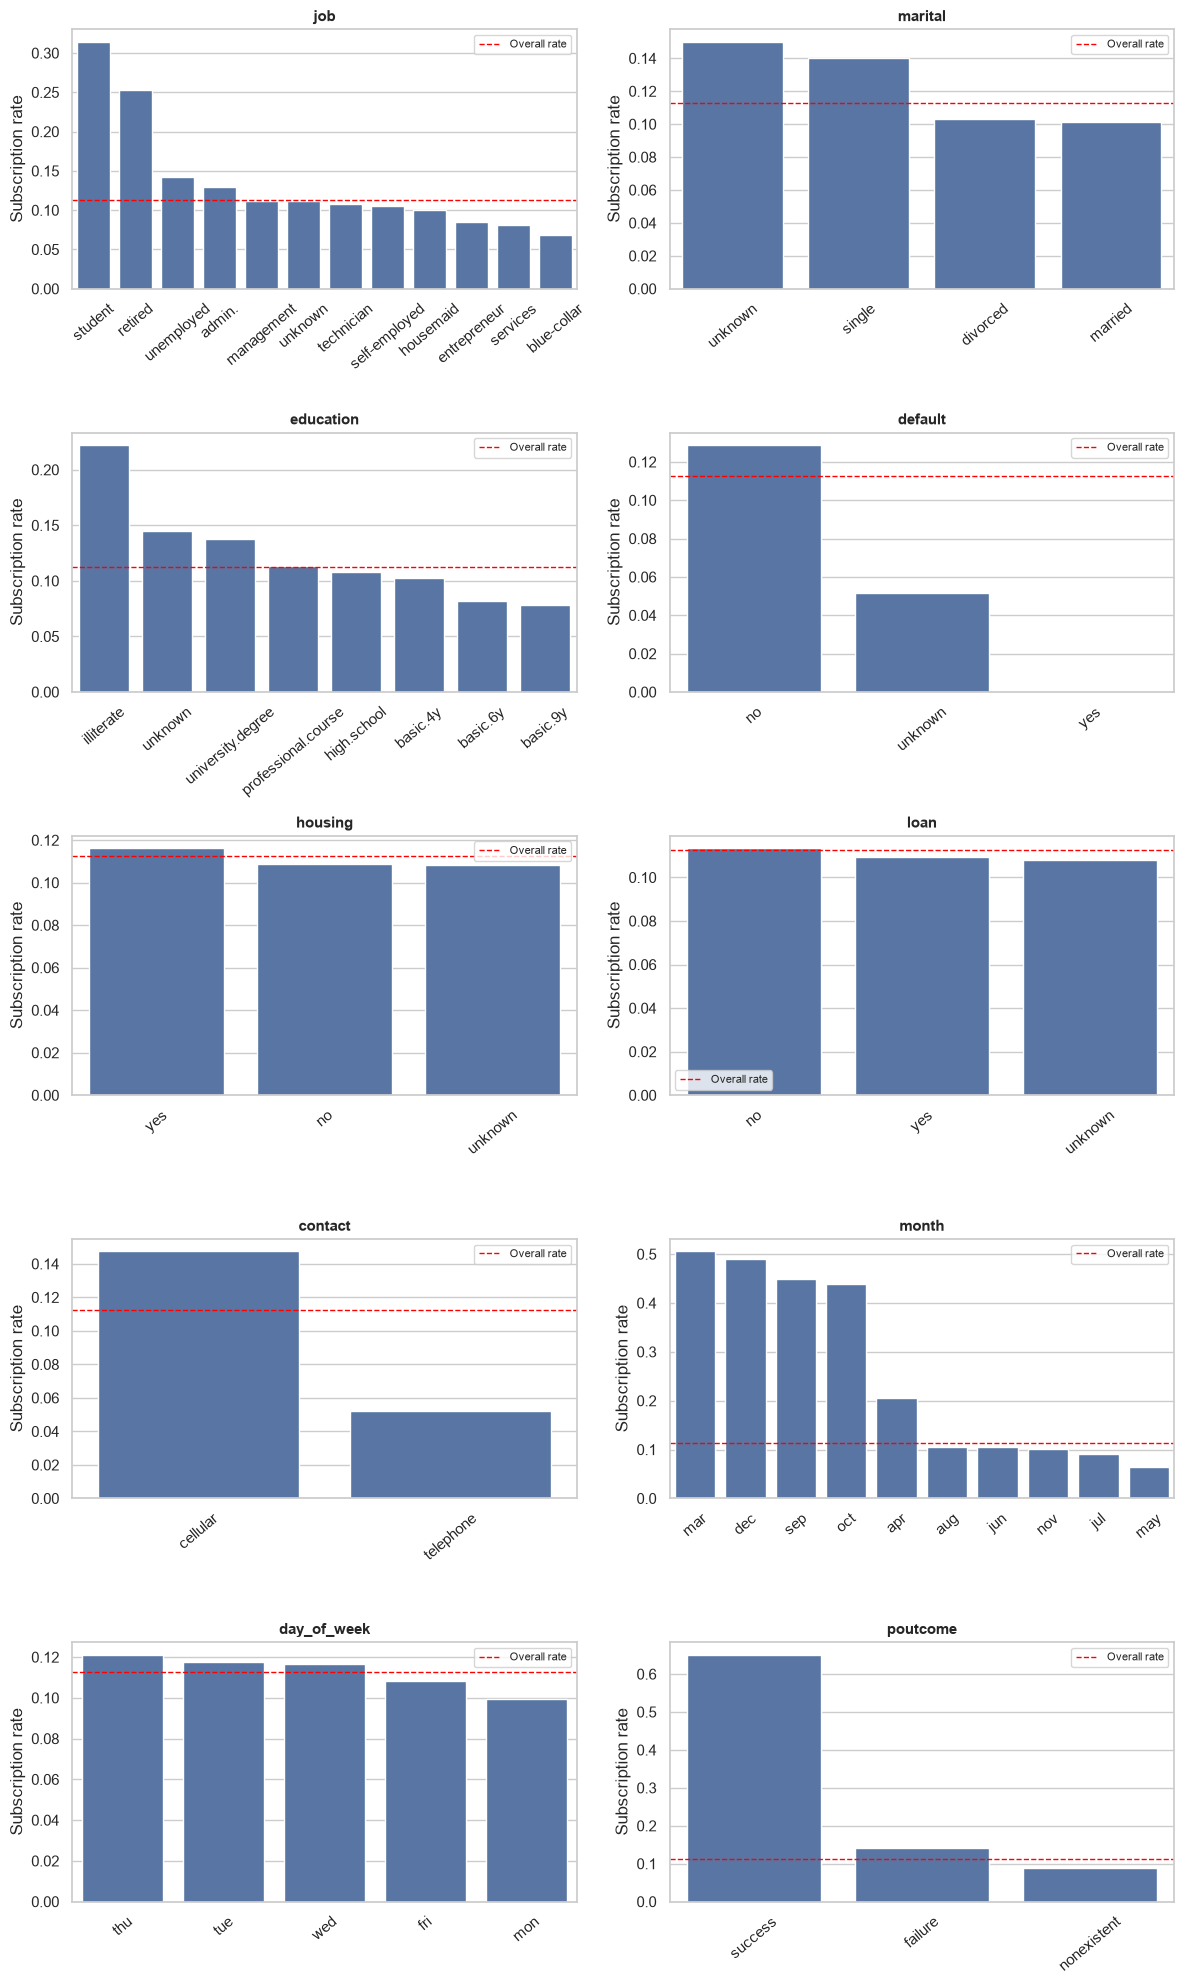

In [17]:
plot_feature_grid(df, categorical_cols, _rate_by_cat_fn, ncols=2, figsize_per_row=4,
                   target=target_col, positive_label=profile["target_positive_label"],
                   save_as="subscription_rate_by_categorical_feature")

### 6.2 Chi-Square Test + Cramér's V

In [18]:
chi_square_results = []
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df[target_col])
    chi2, p_value, dof, _ = chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    chi_square_results.append({
        "Feature": col, "Chi2_Statistic": chi2, "p_value": p_value,
        "Degrees_of_Freedom": dof, "Cramers_V": cramers_v,
    })

independence_categorical = pd.DataFrame(chi_square_results)

def classify_cramers_v(v):
    if v < 0.10: return "Negligible"
    elif v < 0.20: return "Weak"
    elif v < 0.40: return "Moderate"
    elif v < 0.60: return "Strong"
    return "Very Strong"

independence_categorical["Association_Strength"] = independence_categorical["Cramers_V"].apply(classify_cramers_v)
independence_categorical["Significance"] = independence_categorical["p_value"].apply(
    lambda p: "Significant" if p <= 0.05 else "Not Significant")
independence_categorical = independence_categorical.sort_values(
    "Cramers_V", ascending=False).reset_index(drop=True)
independence_categorical

,Feature,Chi2_Statistic,p_value,Degrees_of_Freedom,Cramers_V,Association_Strength,Significance
0,poutcome,4230.523798,0.000000e+00,2,0.320488,Moderate,Significant
1,month,3101.149351,0.000000e+00,9,0.274395,Moderate,Significant
2,job,961.242440,4.189763e-199,11,0.152768,Weak,Significant
3,contact,862.318364,1.525986e-189,1,0.144693,Weak,Significant
4,default,406.577515,5.161958e-89,2,0.099354,Negligible,Significant
5,education,193.105905,3.305189e-38,7,0.068472,Negligible,Significant
6,marital,122.655152,2.068015e-26,3,0.054570,Negligible,Significant
7,day_of_week,26.144939,2.958482e-05,4,0.025195,Negligible,Significant
8,housing,5.684496,5.829448e-02,2,0.011748,Negligible,Not Significant
9,loan,1.094028,5.786753e-01,2,0.005154,Negligible,Not Significant


**Note on `"unknown"`:** it is left in as its own category here
deliberately (not dropped, not imputed) for EDA purposes, whether
`default == "unknown"` itself associates with the target is informative
in its own right (e.g. non-disclosure could correlate with outcome). The
encoding decision for `"unknown"` (separate category vs. imputed) is made
in Notebook 03, informed by this.

## 7. Numerical ↔ Numerical - Multicollinearity

Correlations, VIF, and the condition number below all use
`model_numerical_features` (leakage excluded, `pdays` sentinel handled)
the same feature set that will actually go into a model, not the raw
columns from the file.

### 7.1 Pearson & Spearman Correlation

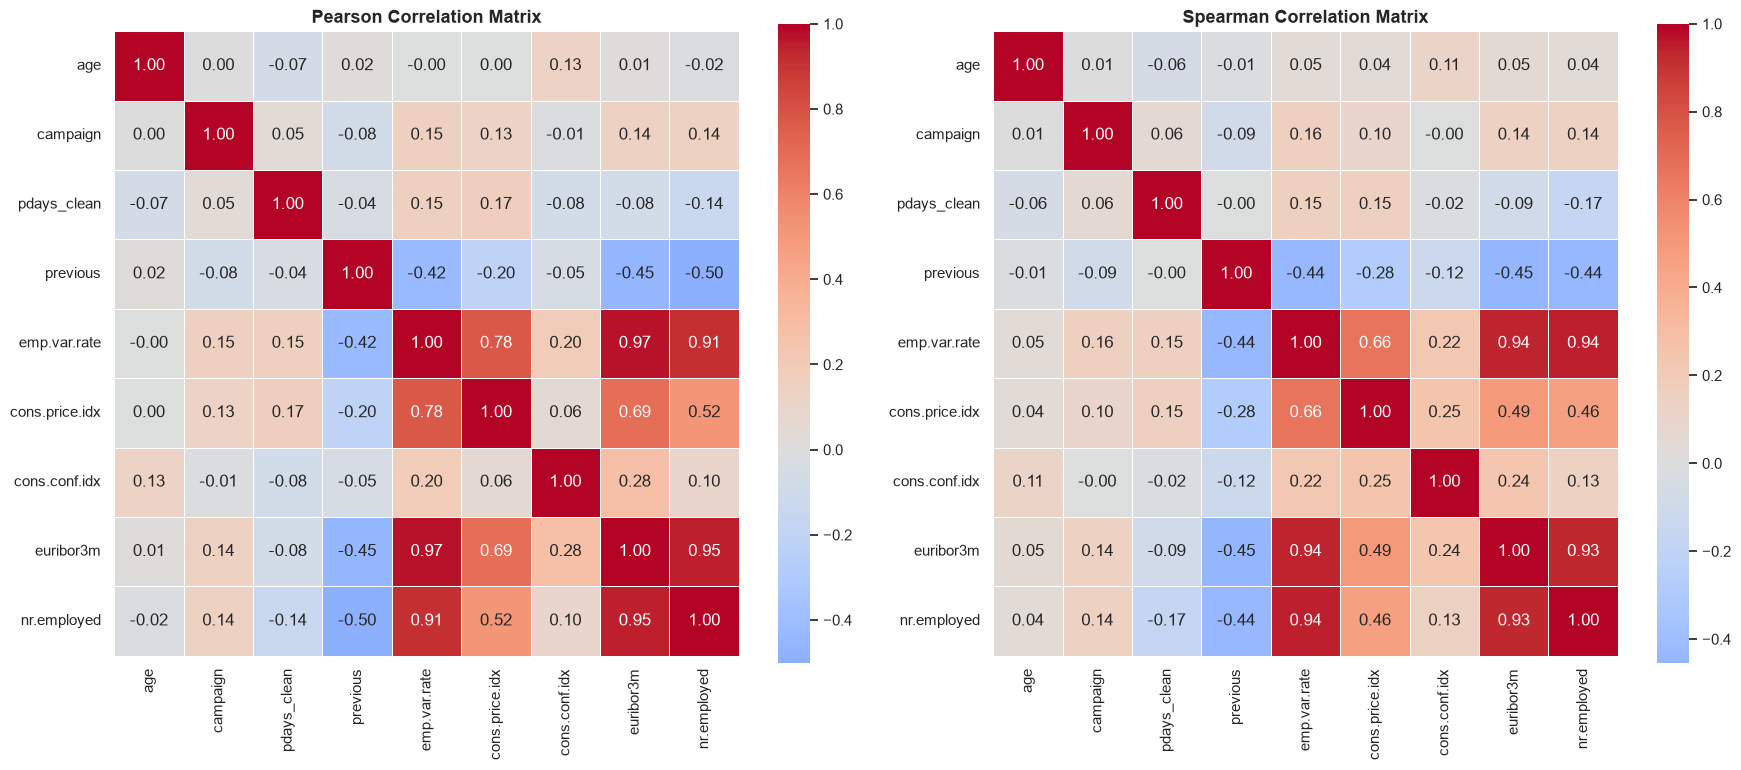

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/02_EDA/correlation_matrices_pearson_spearman.png')

In [19]:
correlation_matrix = df[model_numerical_features].corr(method="pearson")
spearman_matrix = df[model_numerical_features].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5), dpi=FIG_DPI)
for ax, mat, name in zip(axes, [correlation_matrix, spearman_matrix], ["Pearson", "Spearman"]):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title(f"{name} Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "correlation_matrices_pearson_spearman", notebook="02_EDA")

### 7.2 Highly Correlated Pairs (|r| ≥ 0.70)

In [20]:
def upper_triangle_pairs(matrix, value_name, threshold=0.70):
    abs_matrix = matrix.abs()
    upper = abs_matrix.where(np.triu(np.ones(abs_matrix.shape), k=1).astype(bool))
    pairs = upper.stack().reset_index()
    pairs.columns = ["Feature_1", "Feature_2", value_name]
    return pairs[pairs[value_name] >= threshold].sort_values(
        value_name, ascending=False).reset_index(drop=True)

pearson_pairs = upper_triangle_pairs(correlation_matrix, "Abs_Pearson_Correlation")
spearman_pairs = upper_triangle_pairs(spearman_matrix, "Abs_Spearman_Correlation")

print("Pearson pairs with |r| >= 0.70:")
display(pearson_pairs)
print("\nSpearman pairs with |rho| >= 0.70:")
display(spearman_pairs)

Pearson pairs with |r| >= 0.70:


,Feature_1,Feature_2,Abs_Pearson_Correlation
0,emp.var.rate,euribor3m,0.972245
1,euribor3m,nr.employed,0.945154
2,emp.var.rate,nr.employed,0.906970
3,emp.var.rate,cons.price.idx,0.775334



Spearman pairs with |rho| >= 0.70:


,Feature_1,Feature_2,Abs_Spearman_Correlation
0,emp.var.rate,nr.employed,0.944702
1,emp.var.rate,euribor3m,0.939915
2,euribor3m,nr.employed,0.928857


The macro-economic block (`emp.var.rate`, `euribor3m`, `nr.employed`,
`cons.price.idx`) is exactly the cluster Notebook 01 flagged as a disguised
timestamp (Section 8 there) this is the multicollinearity signature that
finding predicted, now confirmed numerically. This has a direct feature
engineering implication: these four columns carry heavily overlapping
information and are candidates for dimensionality reduction (e.g. a single
PCA component) rather than being fed into a linear model as four separate,
near-collinear features.

### 7.3 Variance Inflation Factor (VIF)

In [21]:
X_vif = df[model_numerical_features].copy()
imputer = SimpleImputer(strategy="median")
X_vif_imputed = pd.DataFrame(imputer.fit_transform(X_vif), columns=model_numerical_features)

vif_results = []
for i, feature in enumerate(X_vif_imputed.columns):
    vif = variance_inflation_factor(X_vif_imputed.values, i)
    vif_results.append({"Feature": feature, "VIF": vif})

vif_summary = pd.DataFrame(vif_results)

def classify_vif(vif):
    if vif < 5: return "Low"
    elif vif < 10: return "Moderate"
    return "High"

vif_summary["VIF_Level"] = vif_summary["VIF"].apply(classify_vif)
vif_summary = vif_summary.sort_values("VIF", ascending=False).reset_index(drop=True)
vif_summary

,Feature,VIF,VIF_Level
0,nr.employed,26255.523713,High
1,cons.price.idx,22358.999266,High
2,euribor3m,226.793445,High
3,cons.conf.idx,118.223060,High
4,pdays_clean,68.564382,High
5,emp.var.rate,28.976689,High
6,age,16.051506,High
7,campaign,1.912520,Low
8,previous,1.504454,Low


### 7.4 Condition Number

In [22]:
X_condition = X_vif_imputed.copy()
X_scaled = StandardScaler().fit_transform(X_condition)
condition_number = np.linalg.cond(X_scaled)
print(f"Condition Number: {condition_number:.2f}")
print("(> 30 is commonly flagged as concerning multicollinearity)")

Condition Number: 18.78
(> 30 is commonly flagged as concerning multicollinearity)


### 7.5 Scatter Plots - Strongest Pairs

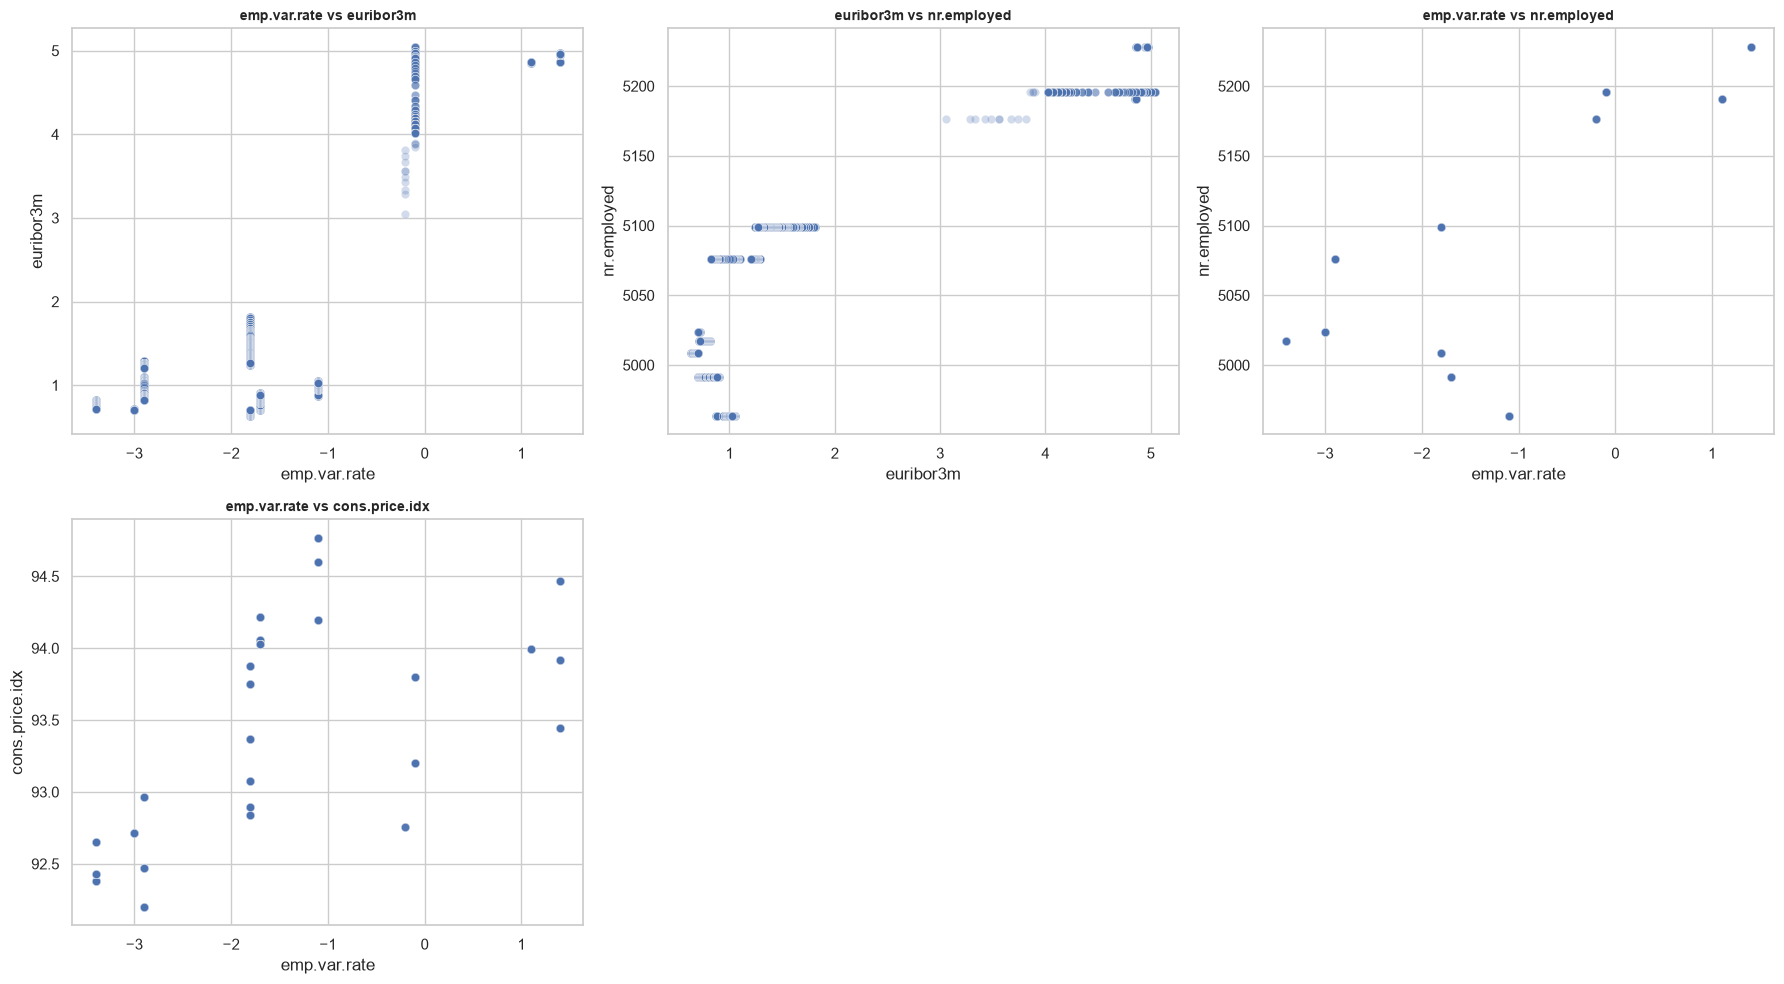

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/02_EDA/top_correlated_pairs_scatter.png')

In [23]:
top_pairs = list(zip(pearson_pairs["Feature_1"].head(6), pearson_pairs["Feature_2"].head(6)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=FIG_DPI)
axes = axes.flatten()
for i, (f1, f2) in enumerate(top_pairs):
    sns.scatterplot(data=df, x=f1, y=f2, alpha=0.25, ax=axes[i])
    axes[i].set_title(f"{f1} vs {f2}", fontsize=10, fontweight="bold")
for j in range(len(top_pairs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
save_fig(fig, "top_correlated_pairs_scatter", notebook="02_EDA")

## 8. Time Structure - Trend Visualization

Notebook 01 established *structurally* that the five macro-economic
columns are a disguised timestamp and that rows are stored in chronological
order (Sections 8/8.1 there). This section delivers the visualisation that
finding promised: what actually happens to the subscription rate as the
underlying economic cycle moves.

### 8.1 Subscription Rate Over the File (Row-Order Proxy for Time)

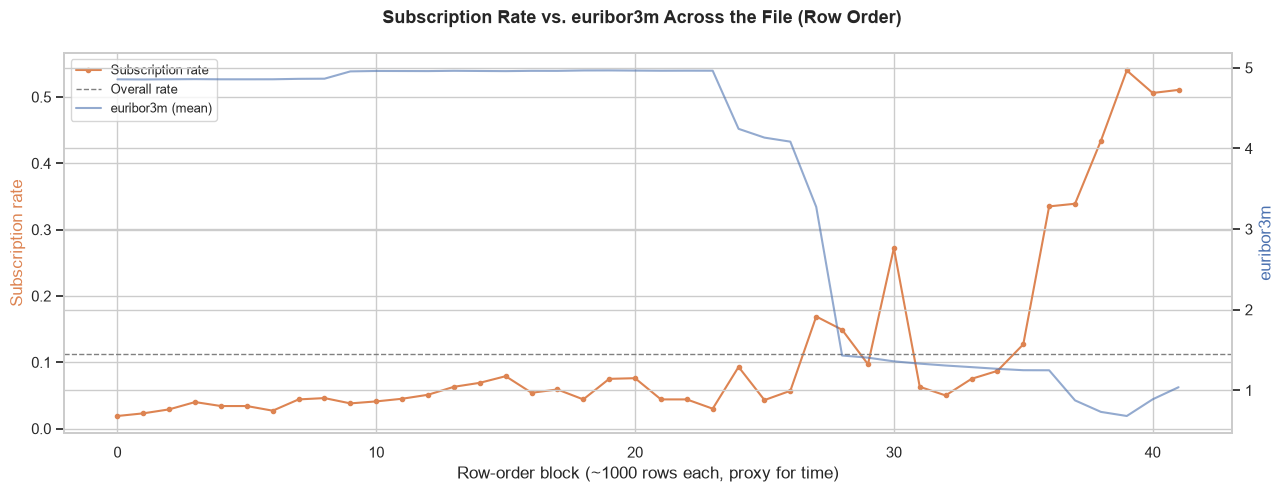

In [24]:
BLOCK_SIZE = 1000
df["_time_block"] = df.index // BLOCK_SIZE

block_summary = df.groupby("_time_block").agg(
    subscription_rate=(target_col, lambda s: (s == "yes").mean()),
    euribor3m=("euribor3m", "mean"),
    emp_var_rate=("emp.var.rate", "mean"),
    n=(target_col, "count"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5), dpi=FIG_DPI)
ax1.plot(block_summary["_time_block"], block_summary["subscription_rate"],
         color="#DD8452", marker="o", markersize=3, label="Subscription rate")
ax1.axhline(profile["target_positive_rate"], color="gray", linestyle="--",
            linewidth=1, label="Overall rate")
ax1.set_xlabel(f"Row-order block (~{BLOCK_SIZE} rows each, proxy for time)")
ax1.set_ylabel("Subscription rate", color="#DD8452")

ax2 = ax1.twinx()
ax2.plot(block_summary["_time_block"], block_summary["euribor3m"],
         color="#4C72B0", alpha=0.6, label="euribor3m (mean)")
ax2.set_ylabel("euribor3m", color="#4C72B0")

fig.suptitle("Subscription Rate vs. euribor3m Across the File (Row Order)",
             fontsize=13, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
plt.tight_layout()
save_fig(fig, "subscription_rate_vs_euribor3m_over_time", notebook="02_EDA")

df.drop(columns=["_time_block"], inplace=True)

**The subscription rate rises sharply as `euribor3m` collapses**
this is the 2008-2009 financial crisis period (Notebook 01, Section 8.1),
and it visibly coincides with a large jump in conversion rate. This is
exactly why the macro-economic columns cannot be treated as independent,
stable customer attributes: a big part of what they're capturing is *which
period this contact happened in*, and that period has a large, direct
relationship with the outcome.

### 8.2 Subscription Rate by Month

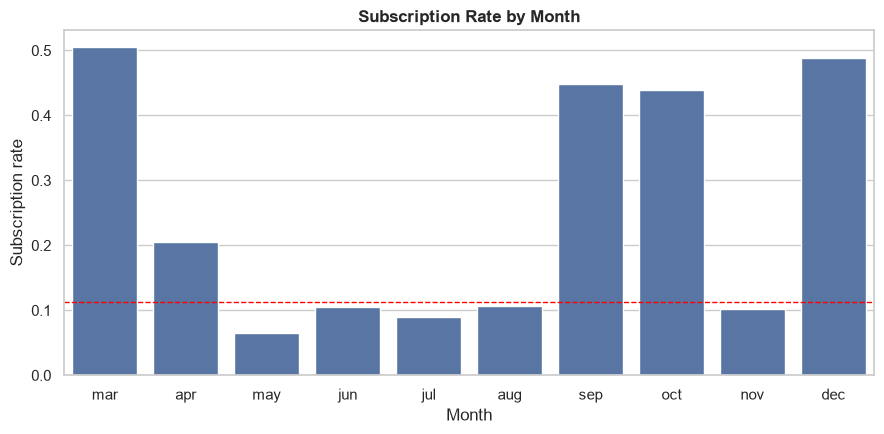

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/02_EDA/subscription_rate_by_month.png')

In [25]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_rate = (df[df["month"].isin(month_order)]
              .groupby("month")[target_col]
              .apply(lambda s: (s == "yes").mean())
              .reindex(month_order))

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=FIG_DPI)
sns.barplot(x=month_rate.index, y=month_rate.values, ax=ax, color="#4C72B0")
ax.axhline(profile["target_positive_rate"], color="red", linestyle="--", linewidth=1)
ax.set_title("Subscription Rate by Month", fontsize=12, fontweight="bold")
ax.set_ylabel("Subscription rate"); ax.set_xlabel("Month")
plt.tight_layout()
save_fig(fig, "subscription_rate_by_month", notebook="02_EDA")

`mar`, `sep`, `oct`, `dec` the lowest-volume months (Notebook 01,
Section 5) show a **much higher** subscription rate than the
high-volume `may`/`jul`/`aug`. This is consistent with the campaign
calling far more people during the high-rate months but converting a
smaller share of them, and is a candidate signal for feature engineering
(e.g. a `low_volume_month` flag) to be decided in Notebook 03/07, not
here.

## 9. Multivariate Snapshot `poutcome` × `month` Interaction

One targeted multivariate cut, not an exhaustive search: does the
previous-campaign outcome's effect on subscription hold steady across
months, or does it interact with the time/economic-cycle signal from
Section 8?

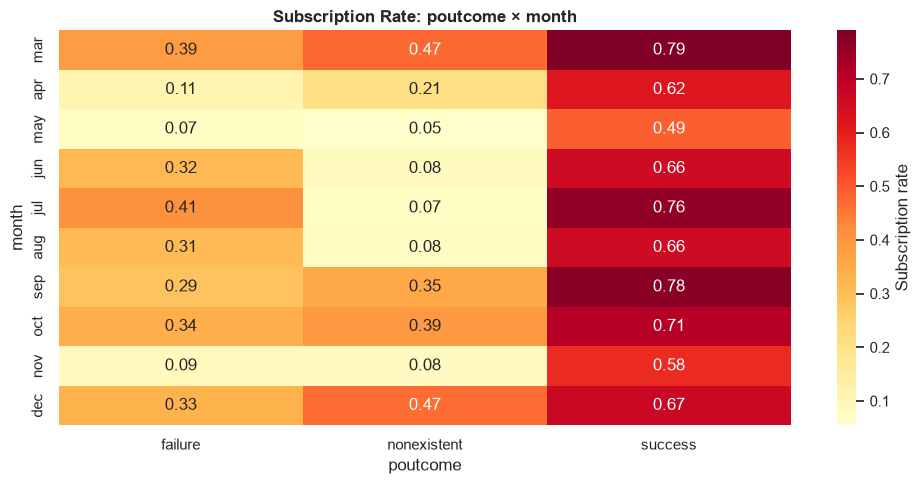

WindowsPath('D:/Important Files/Wapexp Institute/Project 1/Machine Learning Projects/Marketing Campaign Response Modelling/outputs/02_EDA/subscription_rate_poutcome_by_month_heatmap.png')

In [26]:
pivot = (df.pivot_table(index="month", columns="poutcome", values=target_col,
                        aggfunc=lambda s: (s == "yes").mean())
         .reindex(month_order))

fig, ax = plt.subplots(figsize=(10, 5), dpi=FIG_DPI)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Subscription rate"})
ax.set_title("Subscription Rate: poutcome × month", fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "subscription_rate_poutcome_by_month_heatmap", notebook="02_EDA")

`poutcome == "success"` carries a high subscription rate across
almost every month it appears in the effect looks additive rather than
interacting strongly with the time signal. This is a useful sanity check
before feature engineering: `poutcome` looks like a robust standalone
signal, not one that only works in certain economic periods.

## 10. Numerical ↔ Numerical Independence - Consolidated View

Same correlation matrices as Section 7, restated here as a flat pairwise
table (all pairs above a lower, exploratory threshold) so it can be
scanned and exported alongside the categorical association table in
Section 11.

In [27]:
upper_mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
rows = []
feats = model_numerical_features
for i in range(len(feats)):
    for j in range(i + 1, len(feats)):
        f1, f2 = feats[i], feats[j]
        rows.append({
            "Feature_1": f1, "Feature_2": f2,
            "Pearson_r": correlation_matrix.loc[f1, f2],
            "Spearman_rho": spearman_matrix.loc[f1, f2],
        })

numerical_pairs = pd.DataFrame(rows)
numerical_pairs["Abs_Pearson"] = numerical_pairs["Pearson_r"].abs()
numerical_pairs["Abs_Spearman"] = numerical_pairs["Spearman_rho"].abs()
numerical_pairs = numerical_pairs.sort_values("Abs_Pearson", ascending=False).reset_index(drop=True)

associated_pairs = numerical_pairs[
    (numerical_pairs["Abs_Pearson"] >= 0.30) | (numerical_pairs["Abs_Spearman"] >= 0.30)
].copy()
associated_pairs

,Feature_1,Feature_2,Pearson_r,Spearman_rho,Abs_Pearson,Abs_Spearman
0,emp.var.rate,euribor3m,0.972245,0.939915,0.972245,0.939915
1,euribor3m,nr.employed,0.945154,0.928857,0.945154,0.928857
2,emp.var.rate,nr.employed,0.906970,0.944702,0.906970,0.944702
3,emp.var.rate,cons.price.idx,0.775334,0.664890,0.775334,0.664890
4,cons.price.idx,euribor3m,0.688230,0.490970,0.688230,0.490970
5,cons.price.idx,nr.employed,0.522034,0.464738,0.522034,0.464738
6,previous,nr.employed,-0.501333,-0.438721,0.501333,0.438721
7,previous,euribor3m,-0.454494,-0.454724,0.454494,0.454724
8,previous,emp.var.rate,-0.420489,-0.435293,0.420489,0.435293


## 11. Key EDA Findings

- **Target imbalance confirmed visually**: ~11.3% positive, consistent
  with Notebook 01. PR-AUC + lift@10%/20% remain the metrics of record.
- **`pdays` had to be desentineled before any statistic was trustworthy**
  raw `pdays` skew/variance/correlation are dominated by the 999 sentinel,
  not by the 1,515 rows of real signal. `pdays_clean` + `pdays_missing`
  are the two derived views to carry into feature engineering.
- **`duration` reconfirmed as leakage** in this notebook's own data (corr
  0.41) and excluded from every other analysis, as decided in Notebook 01.
- **Effect sizes, not p-values, separate the numerically strong features
  from the numerically trivial ones** at this sample size nearly every
  numerical feature is "statistically significant" against the target;
  Cohen's d is what actually orders them.
- **The four macro-economic columns are highly multicollinear with each
  other** (confirming Notebook 01's "disguised timestamp" structural
  finding) and are candidates for dimensionality reduction rather than
  being used as four independent linear features.
- **Subscription rate visibly tracks the 2008-2009 rate collapse** the
  time-structure claim from Notebook 01 is now shown, not just argued.
  Low-volume months (`mar`, `sep`, `oct`, `dec`) convert at a notably
  higher rate than high-volume months.
- **`poutcome == "success"` looks like a robust, largely time-independent
  signal** its high conversion rate holds across most months it appears
  in, rather than being concentrated in a specific period.
- **Categorical `"unknown"` levels are visibly small relative to real
  categories** (Section 4) supports Notebook 01's framing that `"unknown"`
  is a minority disguised-missing signal, not a dominant one, in most of
  the six affected columns (with `default` as the one exception at ~21%).

**Feature engineering implications carried into `07_feature_engineering`:**
`pdays_missing` + `pdays_clean` as two features (not raw `pdays`); a
possible single macro-economic composite (PCA or index) in place of four
collinear raw columns; `duration` permanently excluded; `poutcome`/`previous`
preferred over `pdays` for a "was contacted before" flag (Notebook 01,
Section 7); a possible `low_volume_month` or cyclical month encoding.

## 12. Save EDA Artifacts

Machine-readable, in the same pattern Notebook 01 established, so
Notebook 03 imports these numbers instead of re-deriving them.

In [28]:
Path("../reports").mkdir(parents=True, exist_ok=True)

eda_summary = {
    "model_numerical_features": model_numerical_features,
    "pdays_sentinel_handling": {
        "pdays_missing_rate": float(df["pdays_missing"].mean()),
        "derived_columns": ["pdays_missing", "pdays_clean"],
    },
    "target_positive_rate": float((df[target_col] == "yes").mean()),
    "high_correlation_pairs_pearson_0_70": pearson_pairs.to_dict(orient="records"),
    "vif_summary": vif_summary.to_dict(orient="records"),
    "condition_number": float(condition_number),
    "cohens_d_by_feature": (mean_comparison_results[["Feature", "Cohens_d", "Effect_Size"]]
                             .to_dict(orient="records")),
    "cramers_v_by_categorical_feature": (independence_categorical[["Feature", "Cramers_V",
                                                                     "Association_Strength"]]
                                          .to_dict(orient="records")),
    "macro_economic_multicollinearity_note": (
        "emp.var.rate, euribor3m, nr.employed, cons.price.idx form a highly "
        "correlated cluster consistent with Notebook 01's disguised-timestamp finding."
    ),
    "feature_engineering_candidates": [
        "pdays_missing (binary flag)",
        "pdays_clean (sentinel replaced with NaN, to be imputed downstream)",
        "macro-economic composite (PCA/index) in place of 4 raw collinear columns",
        "previous / poutcome preferred over pdays for prior-contact flag",
        "low_volume_month or cyclical month encoding",
    ],
}

with open("../reports/eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2, default=str)

mean_comparison_results.to_csv("../reports/eda_numerical_vs_target.csv", index=False)
independence_categorical.to_csv("../reports/eda_categorical_vs_target.csv", index=False)
vif_summary.to_csv("../reports/eda_vif_summary.csv", index=False)

print("Saved -> ../reports/eda_summary.json")
print("Saved -> ../reports/eda_numerical_vs_target.csv")
print("Saved -> ../reports/eda_categorical_vs_target.csv")
print("Saved -> ../reports/eda_vif_summary.csv")

Saved -> ../reports/eda_summary.json
Saved -> ../reports/eda_numerical_vs_target.csv
Saved -> ../reports/eda_categorical_vs_target.csv
Saved -> ../reports/eda_vif_summary.csv


## Conclusion

This notebook explored the dataset univariate → bivariate → multivariate,
built entirely on top of Notebook 01's profile rather than re-deriving
column roles from scratch, and delivered the two visualisations Notebook 01
promised but did not itself produce: the class-imbalance chart and the
time-trend chart. The `pdays` sentinel was neutralised before any statistic
used it, and `duration` was kept excluded throughout, per Notebook 01.

**Next notebook: `03_data_cleaning_preprocessing`** encode categoricals
(with `education`'s ordinal structure and `"unknown"` handling decided
per-column), impute `pdays_clean`, decide the duplicate-rows question left
open in Notebook 01 Section 8 (informed by the target-rate skew already
computed there), and drop `duration`.